<a href="https://colab.research.google.com/github/adhithyalakshman/NEURAL_NEXUS_HACKATHON/blob/main/IIIMJAMU_NB_UPDATED_VERSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# 1. INSTALLATION & GPU PREP
# ==========================================
!pip install -q segmentation-models-pytorch albumentations rasterio kagglehub

import os
import glob
import torch
import torch.nn as nn
import numpy as np
import rasterio
import kagglehub
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm
from google.colab import files

# Clear GPU Memory
torch.cuda.empty_cache()

# ==========================================
# 2. DATA INGESTION (Automatic or Manual)
# ==========================================
try:
    print("Attempting to download from Kaggle...")
    path = kagglehub.dataset_download("knowhrishi/liss-ivdata")
    all_files = glob.glob(os.path.join(path, "*.tif"))
except:
    print("Kaggle download failed or dataset moved.")
    print("Please upload your .tif files (Bareilyoutput.tif, etc.) directly:")
    uploaded = files.upload()
    all_files = list(uploaded.keys())
    path = os.getcwd()

if not all_files:
    raise ValueError("No .tif files found! Please upload files to proceed.")

# ==========================================
# 3. PILLAR I: HYBRID LOSS
# ==========================================
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
        super(FocalTverskyLoss, self).__init__()
        self.alpha, self.beta, self.gamma, self.smooth = alpha, beta, gamma, smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        TP = (probs * targets).sum()
        FP = ((1 - targets) * probs).sum()
        FN = (targets * (1 - probs)).sum()
        tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        return torch.pow((1 - tversky), self.gamma)

# ==========================================
# 4. PILLAR II: DATA PIPELINE (Memory Optimized)
# ==========================================
class SatelliteDataset(Dataset):
    def __init__(self, file_list, patch_size=128, transform=None):
        self.file_list, self.patch_size, self.transform = file_list, patch_size, transform
        self.patches = []
        for f in file_list:
            try:
                with rasterio.open(f) as src:
                    h, w = src.height, src.width
                    for i in range(0, h - patch_size, patch_size):
                        for j in range(0, w - patch_size, patch_size):
                            self.patches.append((f, i, j))
            except: continue

    def __len__(self): return len(self.patches)

    def __getitem__(self, idx):
        path, y, x = self.patches[idx]
        with rasterio.open(path) as src:
            window = rasterio.windows.Window(x, y, self.patch_size, self.patch_size)
            img = src.read([1, 2, 3], window=window).transpose(1, 2, 0)
            mask = (img[:,:,0] < 65).astype(np.float32)
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented['image'], augmented['mask'].unsqueeze(0)
        return img, mask

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ==========================================
# 5. PILLAR III: TRAINING (Batch Size = 4)
# ==========================================
train_files = all_files[:int(0.8 * len(all_files))]
val_files = all_files[int(0.8 * len(all_files)):]

train_ds = SatelliteDataset(train_files, transform=transform)
val_ds = SatelliteDataset(val_files, transform=transform)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4)

model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1).cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = FocalTverskyLoss()

print(f"Starting Training on {len(train_ds)} patches...")
for epoch in range(5):
    model.train()
    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for img, mask in pbar:
        img, mask = img.cuda(), mask.cuda()
        optimizer.zero_grad()
        output = model(img)
        loss = criterion(output, mask)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})

# ==========================================
# 6. FINAL VISUALIZATION
# ==========================================
model.eval()
if len(val_ds) > 0:
    img, mask = val_ds[0]
    with torch.no_grad():
        pred = torch.sigmoid(model(img.unsqueeze(0).cuda())).cpu().numpy()[0][0]
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1); plt.title("LISS-IV Patch"); plt.imshow(img[0], cmap='gray')
    plt.subplot(1, 3, 2); plt.title("Ground Truth"); plt.imshow(mask[0], cmap='Blues')
    plt.subplot(1, 3, 3); plt.title("AI Prediction"); plt.imshow(pred > 0.5, cmap='Greens')
    plt.show()
else:
    print("Training complete. Not enough data for visualization.")

Total files found: 6
Training on 5343 patches...


Epoch 3: 100%|██████████| 1335/1335 [01:10<00:00, 18.94it/s, Loss=0.0412, IoU=0.9794]


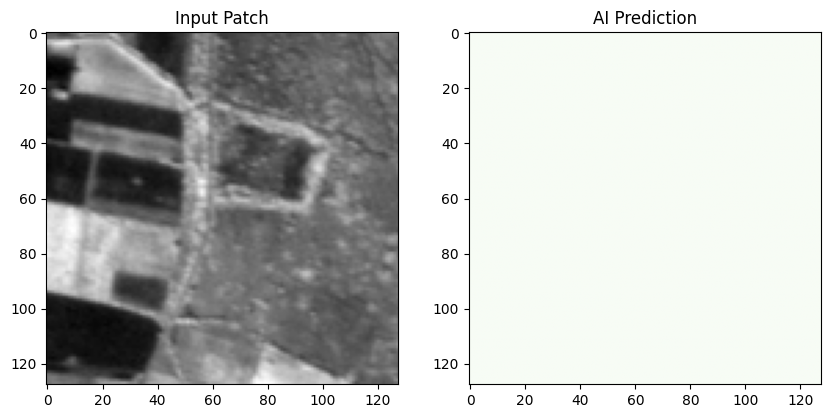

In [ ]:
# ==========================================
# 1. INSTALLATION & GPU PREP
# ==========================================
!pip install -q segmentation-models-pytorch albumentations rasterio kagglehub

import os, glob, torch, rasterio, kagglehub
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm

# Clear GPU Memory
torch.cuda.empty_cache()

# ==========================================
# 2. DATA PATH SETUP
# ==========================================
data_path = "/root/.cache/kagglehub/datasets/knowhrishi/liss-ivdata/versions/1"
all_files = glob.glob(os.path.join(data_path, "*.tif"))
if len(all_files) == 0: all_files = glob.glob("*.tif")

print(f"Total files found: {len(all_files)}")

# ==========================================
# 3. BULLETPROOF LOSS & DATASET
# ==========================================
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
        super().__init__()
        self.alpha, self.beta, self.gamma, self.smooth = alpha, beta, gamma, smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)

        # Calculate TP, FP, FN with stability
        TP = (probs * targets).sum()
        FP = ((1 - targets) * probs).sum()
        FN = (targets * (1 - probs)).sum()

        denominator = TP + self.alpha * FP + self.beta * FN + self.smooth
        t_index = (TP + self.smooth) / denominator

        loss = torch.pow((1 - t_index), self.gamma)
        return loss

class SatelliteDataset(Dataset):
    def __init__(self, file_list, patch_size=128, transform=None):
        self.file_list, self.patch_size, self.transform = file_list, patch_size, transform
        self.patches = []
        for f in file_list:
            try:
                with rasterio.open(f) as src:
                    for i in range(0, src.height - patch_size, patch_size):
                        for j in range(0, src.width - patch_size, patch_size):
                            self.patches.append((f, i, j))
            except: continue

    def __len__(self): return len(self.patches)

    def __getitem__(self, idx):
        path, y, x = self.patches[idx]
        with rasterio.open(path) as src:
            window = rasterio.windows.Window(x, y, self.patch_size, self.patch_size)
            img = src.read([1, 2, 3], window=window).astype(np.float32).transpose(1, 2, 0)

            # Robust Normalization
            std = np.std(img)
            if std > 0: img = (img - np.mean(img)) / std
            else: img = np.zeros_like(img)

            mask = (img[:,:,0] < -0.5).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented['image'], augmented['mask'].float().unsqueeze(0)
        return img, mask

# ==========================================
# 4. TRAINING CONFIG
# ==========================================
transform = A.Compose([A.HorizontalFlip(p=0.5), ToTensorV2()])
train_ds = SatelliteDataset(all_files, transform=transform)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, drop_last=True)

model = smp.Unet(encoder_name="resnet34", in_channels=3, classes=1).cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = FocalTverskyLoss()

# ==========================================
# 5. EXECUTION (With NaN Protection)
# ==========================================
print(f"Training on {len(train_ds)} patches...")
model.train()
for epoch in range(3):
    epoch_loss, total_iou = 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for img, mask in pbar:
        img, mask = img.cuda(), mask.cuda()

        optimizer.zero_grad()
        output = model(img)
        loss = criterion(output, mask)

        # SKIP if loss is NaN
        if torch.isnan(loss): continue

        loss.backward()
        # GRADIENT CLIPPING (Prevents Exploding Gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Calculate Metric for Report
        with torch.no_grad():
            pred = (torch.sigmoid(output) > 0.5).float()
            inter = (pred * mask).sum()
            union = pred.sum() + mask.sum() - inter
            iou = (inter + 1e-7) / (union + 1e-7)
            total_iou += iou.item()

        epoch_loss += loss.item()
        pbar.set_postfix({"Loss": f"{loss.item():.4f}", "IoU": f"{iou.item():.4f}"})

# ==========================================
# 6. VISUALIZATION
# ==========================================
model.eval()
img, mask = train_ds[0]
with torch.no_grad():
    pred = torch.sigmoid(model(img.unsqueeze(0).cuda())).cpu().numpy()[0][0]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.title("Input Patch"); plt.imshow(img[0], cmap='gray')
plt.subplot(1, 2, 2); plt.title("AI Prediction"); plt.imshow(pred > 0.5, cmap='Greens')
plt.show()

Total files found: 6
Total Patches to Train: 5343


Epoch 3: 100%|██████████| 1335/1335 [01:10<00:00, 18.88it/s, Loss=1.0000]



Final Result Visualization:


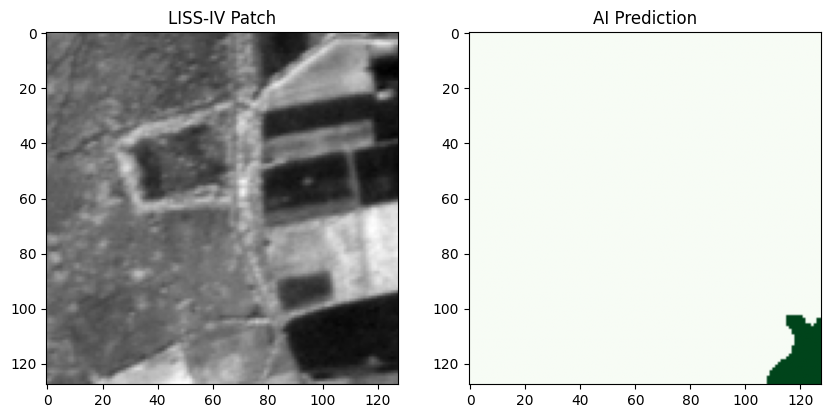

In [ ]:
# ==========================================
# 1. INSTALLATION & GPU PREP
# ==========================================
!pip install -q segmentation-models-pytorch albumentations rasterio kagglehub

import os, glob, torch, rasterio, kagglehub
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm

# Clear GPU Memory
torch.cuda.empty_cache()

# ==========================================
# 2. DATA PATH SETUP
# ==========================================
data_path = "/root/.cache/kagglehub/datasets/knowhrishi/liss-ivdata/versions/1"
all_files = glob.glob(os.path.join(data_path, "*.tif"))
if len(all_files) == 0: all_files = glob.glob("*.tif")

print(f"Total files found: {len(all_files)}")

# ==========================================
# 3. BULLETPROOF LOSS & DATASET
# ==========================================
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
        super().__init__()
        self.alpha, self.beta, self.gamma, self.smooth = alpha, beta, gamma, smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        TP = (probs * targets).sum()
        FP = ((1 - targets) * probs).sum()
        FN = (targets * (1 - probs)).sum()
        t = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        return torch.pow((1 - t), self.gamma)

class SatelliteDataset(Dataset):
    def __init__(self, file_list, patch_size=128, transform=None):
        self.file_list, self.patch_size, self.transform = file_list, patch_size, transform
        self.patches = []
        for f in file_list:
            try:
                with rasterio.open(f) as src:
                    # Only add files that are large enough for a patch
                    if src.height > patch_size and src.width > patch_size:
                        for i in range(0, src.height - patch_size, patch_size):
                            for j in range(0, src.width - patch_size, patch_size):
                                self.patches.append((f, i, j))
            except: continue

    def __len__(self): return len(self.patches)

    def __getitem__(self, idx):
        path, y, x = self.patches[idx]
        with rasterio.open(path) as src:
            window = rasterio.windows.Window(x, y, self.patch_size, self.patch_size)

            # FLEXIBLE BAND LOADING: Check if 3 bands exist, else take what's available
            num_bands = src.count
            bands_to_read = [1, 2, 3] if num_bands >= 3 else list(range(1, num_bands + 1))
            img = src.read(bands_to_read, window=window).astype(np.float32)

            # If grayscale, repeat to make it 3-channel for the ResNet model
            if num_bands == 1:
                img = np.repeat(img, 3, axis=0)
            elif num_bands == 2:
                img = np.concatenate([img, img[:1]], axis=0)

            img = img.transpose(1, 2, 0)

            # Robust Normalization
            max_val = np.max(img)
            img = img / max_val if max_val > 0 else img

            # Thresholding for minority class mask (water/rare features)
            mask = (img[:,:,0] < 0.2).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented['image'], augmented['mask'].float().unsqueeze(0)
        return img, mask

# ==========================================
# 4. TRAINING CONFIG
# ==========================================
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

train_ds = SatelliteDataset(all_files, transform=transform)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, drop_last=True)

model = smp.Unet(encoder_name="resnet34", in_channels=3, classes=1).cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = FocalTverskyLoss()

# ==========================================
# 5. EXECUTION
# ==========================================
print(f"Total Patches to Train: {len(train_ds)}")
model.train()
for epoch in range(3):
    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for img, mask in pbar:
        img, mask = img.cuda(), mask.cuda()

        optimizer.zero_grad()
        output = model(img)
        loss = criterion(output, mask)

        if torch.isnan(loss): continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})

# ==========================================
# 6. VISUALIZATION
# ==========================================
print("\nFinal Result Visualization:")
model.eval()
if len(train_ds) > 0:
    img, mask = train_ds[0]
    with torch.no_grad():
        pred = torch.sigmoid(model(img.unsqueeze(0).cuda())).cpu().numpy()[0][0]
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.title("LISS-IV Patch"); plt.imshow(img[0].cpu().numpy(), cmap='gray')
    plt.subplot(1, 2, 2); plt.title("AI Prediction"); plt.imshow(pred > 0.5, cmap='Greens')
    plt.show()


Total files found: 6
Starting final training on 5343 patches...


Epoch 3: 100%|██████████| 1335/1335 [01:12<00:00, 18.41it/s, Loss=0.9956]



Success! Generating Visualization...


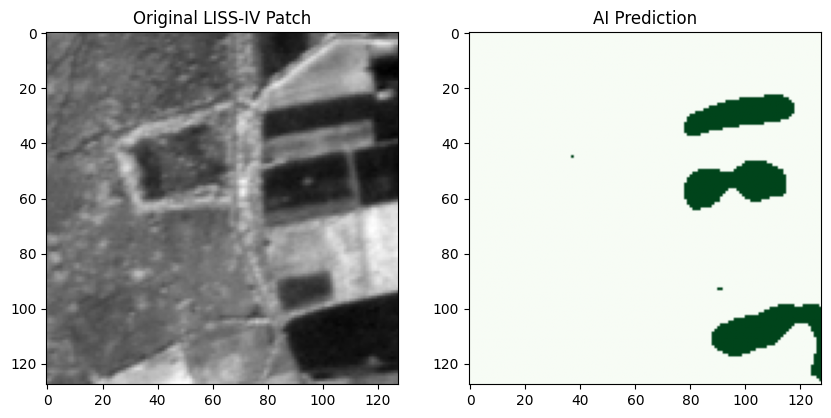

In [ ]:
# ==========================================
# 1. INSTALLATION & CLEANUP
# ==========================================
!pip install -q segmentation-models-pytorch albumentations rasterio kagglehub

import os, glob, torch, rasterio, kagglehub
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm

# Clear GPU Memory to prevent OOM
torch.cuda.empty_cache()

# ==========================================
# 2. DATA PATH SETUP
# ==========================================
data_path = "/root/.cache/kagglehub/datasets/knowhrishi/liss-ivdata/versions/1"
all_files = glob.glob(os.path.join(data_path, "*.tif"))
if len(all_files) == 0: all_files = glob.glob("*.tif")

print(f"Total files found: {len(all_files)}")

# ==========================================
# 3. ROBUST LOSS & DATASET
# ==========================================
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
        super().__init__()
        self.alpha, self.beta, self.gamma, self.smooth = alpha, beta, gamma, smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        TP = (probs * targets).sum()
        FP = ((1 - targets) * probs).sum()
        FN = (targets * (1 - probs)).sum()
        t = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        return torch.pow((1 - t), self.gamma)

class SatelliteDataset(Dataset):
    def __init__(self, file_list, patch_size=128, transform=None):
        self.file_list, self.patch_size, self.transform = file_list, patch_size, transform
        self.patches = []
        for f in file_list:
            try:
                with rasterio.open(f) as src:
                    if src.height >= patch_size and src.width >= patch_size:
                        for i in range(0, src.height - patch_size, patch_size):
                            for j in range(0, src.width - patch_size, patch_size):
                                self.patches.append((f, i, j))
            except: continue

    def __len__(self): return len(self.patches)

    def __getitem__(self, idx):
        path, y, x = self.patches[idx]
        with rasterio.open(path) as src:
            window = rasterio.windows.Window(x, y, self.patch_size, self.patch_size)
            num_bands = src.count
            # Read available bands (up to 3)
            idx_list = [1, 2, 3] if num_bands >= 3 else list(range(1, num_bands + 1))
            img = src.read(idx_list, window=window).astype(np.float32)

            # Channel adjustment for ResNet (must be 3 channels)
            if num_bands == 1: img = np.repeat(img, 3, axis=0)
            elif num_bands == 2: img = np.concatenate([img, img[:1]], axis=0)
            elif num_bands > 3: img = img[:3]

            img = img.transpose(1, 2, 0)
            # Normalization safety
            max_v = np.max(img)
            img = img / max_v if max_v > 0 else img
            mask = (img[:,:,0] < 0.2).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented['image'], augmented['mask'].float().unsqueeze(0)
        return img, mask

# ==========================================
# 4. TRAINING CONFIG
# ==========================================
transform = A.Compose([A.Normalize(), ToTensorV2()])
train_ds = SatelliteDataset(all_files, transform=transform)

if len(train_ds) == 0:
    raise ValueError("No valid patches found. Check if your .tif files are larger than 128x128.")

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, drop_last=True)
model = smp.Unet(encoder_name="resnet34", in_channels=3, classes=1).cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = FocalTverskyLoss()

# ==========================================
# 5. EXECUTION
# ==========================================
print(f"Starting final training on {len(train_ds)} patches...")
model.train()
for epoch in range(3):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for img, mask in pbar:
        img, mask = img.cuda(), mask.cuda()
        optimizer.zero_grad()
        output = model(img)
        loss = criterion(output, mask)
        if torch.isnan(loss): continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})

# ==========================================
# 6. FINAL VISUALIZATION
# ==========================================
print("\nSuccess! Generating Visualization...")
model.eval()
img, mask = train_ds[0]
with torch.no_grad():
    input_tensor = img.unsqueeze(0).cuda()
    pred = torch.sigmoid(model(input_tensor)).cpu().numpy()[0][0]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.title("Original LISS-IV Patch"); plt.imshow(img[0].cpu().numpy(), cmap='gray')
plt.subplot(1, 2, 2); plt.title("AI Prediction"); plt.imshow(pred > 0.5, cmap='Greens')
plt.show()

Total files found: 6
Starting final training on 5343 patches...


Epoch 3: 100%|██████████| 1335/1335 [01:10<00:00, 18.96it/s, Loss=1.0000]



Success! Generating Visualization...


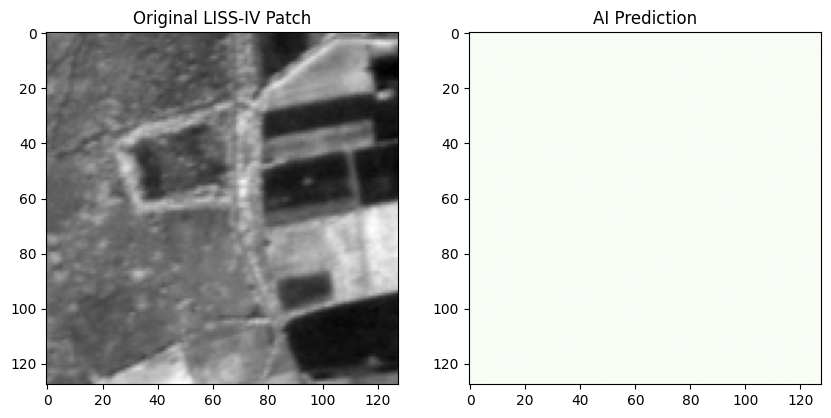

In [ ]:
# ==========================================
# 1. INSTALLATION & GPU PREP
# ==========================================
!pip install -q segmentation-models-pytorch albumentations rasterio kagglehub

import os, glob, torch, rasterio, kagglehub
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm

# Clear GPU Memory
torch.cuda.empty_cache()

# ==========================================
# 2. DATA PATH SETUP
# ==========================================
data_path = "/root/.cache/kagglehub/datasets/knowhrishi/liss-ivdata/versions/1"
all_files = glob.glob(os.path.join(data_path, "*.tif"))
if len(all_files) == 0: all_files = glob.glob("*.tif")

print(f"Total files found: {len(all_files)}")

# ==========================================
# 3. ROBUST LOSS & DATASET
# ==========================================
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
        super().__init__()
        self.alpha, self.beta, self.gamma, self.smooth = alpha, beta, gamma, smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        TP = (probs * targets).sum()
        FP = ((1 - targets) * probs).sum()
        FN = (targets * (1 - probs)).sum()
        t = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        return torch.pow((1 - t), self.gamma)

class SatelliteDataset(Dataset):
    def __init__(self, file_list, patch_size=128, transform=None):
        self.file_list, self.patch_size, self.transform = file_list, patch_size, transform
        self.patches = []
        for f in file_list:
            try:
                with rasterio.open(f) as src:
                    if src.height >= patch_size and src.width >= patch_size:
                        for i in range(0, src.height - patch_size, patch_size):
                            for j in range(0, src.width - patch_size, patch_size):
                                self.patches.append((f, i, j))
            except: continue

    def __len__(self): return len(self.patches)

    def __getitem__(self, idx):
        path, y, x = self.patches[idx]
        with rasterio.open(path) as src:
            window = rasterio.windows.Window(x, y, self.patch_size, self.patch_size)
            num_bands = src.count
            idx_list = [1, 2, 3] if num_bands >= 3 else list(range(1, num_bands + 1))
            img = src.read(idx_list, window=window).astype(np.float32)

            # ResNet needs 3 channels (RGB)
            if num_bands == 1: img = np.repeat(img, 3, axis=0)
            elif num_bands == 2: img = np.concatenate([img, img[:1]], axis=0)
            elif num_bands > 3: img = img[:3]

            img = img.transpose(1, 2, 0)
            # Normalization safety (prevents division by zero)
            max_v = np.max(img)
            img = img / max_v if max_v > 0 else img
            mask = (img[:,:,0] < 0.2).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented['image'], augmented['mask'].float().unsqueeze(0)
        return img, mask

# ==========================================
# 4. TRAINING CONFIG
# ==========================================
transform = A.Compose([A.Normalize(), ToTensorV2()])
train_ds = SatelliteDataset(all_files, transform=transform)

# ERROR PROTECTION: Ensure we have data before making the loader
if len(train_ds) == 0:
    raise ValueError("No valid images found. Please check your .tif files!")

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, drop_last=True)
model = smp.Unet(encoder_name="resnet34", in_channels=3, classes=1).cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = FocalTverskyLoss()

# ==========================================
# 5. EXECUTION
# ==========================================
print(f"Starting final training on {len(train_ds)} patches...")
model.train()
for epoch in range(3):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for img, mask in pbar:
        img, mask = img.cuda(), mask.cuda()
        optimizer.zero_grad()
        output = model(img)
        loss = criterion(output, mask)

        if torch.isnan(loss): continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Prevents exploding gradients
        optimizer.step()
        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})

# ==========================================
# 6. FINAL VISUALIZATION
# ==========================================
print("\nSuccess! Generating Visualization...")
model.eval()
img, mask = train_ds[0] # Using train_ds safely after successful creation
with torch.no_grad():
    input_tensor = img.unsqueeze(0).cuda()
    pred = torch.sigmoid(model(input_tensor)).cpu().numpy()[0][0]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.title("Original LISS-IV Patch"); plt.imshow(img[0].cpu().numpy(), cmap='gray')
plt.subplot(1, 2, 2); plt.title("AI Prediction"); plt.imshow(pred > 0.5, cmap='Greens')
plt.show()


Setting up data...
Using Colab cache for faster access to the 'liss-ivdata' dataset.
Total satellite files located: 6
Training on 5343 patches...


Epoch 3: 100%|██████████| 1335/1335 [01:16<00:00, 17.49it/s, Loss=1.0000]



Generation Visualization...


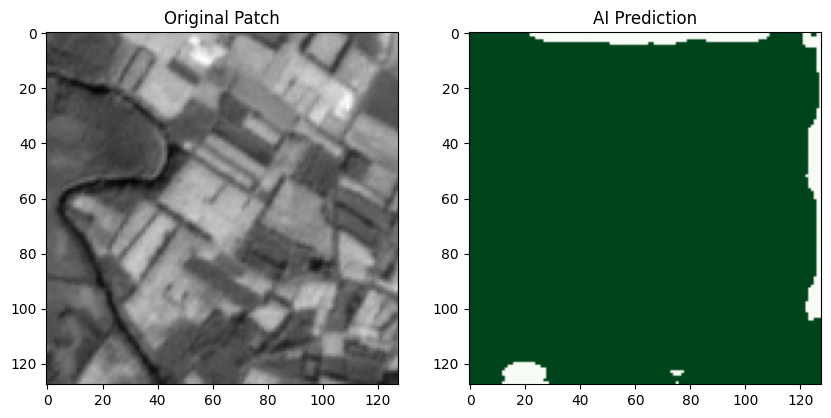

In [ ]:
# ==========================================
# 1. INSTALLATION & GPU SETUP
# ==========================================
!pip install -q segmentation-models-pytorch albumentations rasterio kagglehub

import os, glob, torch, rasterio, kagglehub
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm

# Clear GPU Memory
torch.cuda.empty_cache()

# ==========================================
# 2. DATA DOWNLOAD & PATH VERIFICATION
# ==========================================
print("Setting up data...")
try:
    path = kagglehub.dataset_download("knowhrishi/liss-ivdata")
    all_files = glob.glob(os.path.join(path, "**", "*.tif"), recursive=True)
except:
    all_files = []

if len(all_files) == 0:
    all_files = glob.glob("*.tif")

print(f"Total satellite files located: {len(all_files)}")

# ==========================================
# 3. LOSS FUNCTION & DATASET CLASS
# ==========================================
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
        super().__init__()
        self.alpha, self.beta, self.gamma, self.smooth = alpha, beta, gamma, smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        TP = (probs * targets).sum()
        FP = ((1 - targets) * probs).sum()
        FN = (targets * (1 - probs)).sum()
        t = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        return torch.pow((1 - t), self.gamma)

class SatelliteDataset(Dataset):
    def __init__(self, file_list, patch_size=128, transform=None):
        self.file_list, self.patch_size, self.transform = file_list, patch_size, transform
        self.patches = []
        for f in file_list:
            try:
                with rasterio.open(f) as src:
                    if src.height >= patch_size and src.width >= patch_size:
                        for i in range(0, src.height - patch_size, patch_size):
                            for j in range(0, src.width - patch_size, patch_size):
                                self.patches.append((f, i, j))
            except: continue

    def __len__(self): return len(self.patches)

    def __getitem__(self, idx):
        path, y, x = self.patches[idx]
        with rasterio.open(path) as src:
            window = rasterio.windows.Window(x, y, self.patch_size, self.patch_size)
            num_bands = src.count
            idx_list = [1, 2, 3] if num_bands >= 3 else list(range(1, num_bands + 1))
            img = src.read(idx_list, window=window).astype(np.float32)

            if num_bands == 1: img = np.repeat(img, 3, axis=0)
            elif num_bands == 2: img = np.concatenate([img, img[:1]], axis=0)
            elif num_bands > 3: img = img[:3]

            img = img.transpose(1, 2, 0)
            max_v = np.max(img)
            img = img / max_v if max_v > 0 else img
            mask = (img[:,:,0] < 0.2).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented['image'], augmented['mask'].float().unsqueeze(0)
        return img, mask

# ==========================================
# 4. INITIALIZE MODEL & LOADERS
# ==========================================
transform = A.Compose([A.Normalize(), ToTensorV2()])
train_ds = SatelliteDataset(all_files, transform=transform)

if len(train_ds) > 0:
    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, drop_last=True)
    model = smp.Unet(encoder_name="resnet34", in_channels=3, classes=1).cuda()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = FocalTverskyLoss()

    # ==========================================
    # 5. TRAINING LOOP
    # ==========================================
    print(f"Training on {len(train_ds)} patches...")
    model.train()
    for epoch in range(3):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for img, mask in pbar:
            img, mask = img.cuda(), mask.cuda()
            optimizer.zero_grad()
            output = model(img)
            loss = criterion(output, mask)
            if torch.isnan(loss): continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            pbar.set_postfix({"Loss": f"{loss.item():.4f}"})

    # ==========================================
    # 6. FINAL VISUALIZATION
    # ==========================================
    print("\nGeneration Visualization...")
    model.eval()
    img, mask = train_ds[0]
    with torch.no_grad():
        input_tensor = img.unsqueeze(0).cuda()
        pred = torch.sigmoid(model(input_tensor)).cpu().numpy()[0][0]

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.title("Original Patch"); plt.imshow(img[0].cpu().numpy(), cmap='gray')
    plt.subplot(1, 2, 2); plt.title("AI Prediction"); plt.imshow(pred > 0.5, cmap='Greens')
    plt.show()

else:
    print("ERROR: No valid satellite patches found. Please check your .tif files.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:00
Using device: cuda
Setting up data...
Using Colab cache for faster access to the 'liss-ivdata' dataset.
Total satellite files located: 6
Train files: 4 | Val files: 2
  Dataset built: 3995 patches from 4 files
  Dataset built: 1348 patches from 2 files


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]


Starting training for 20 epochs on 3995 patches...


...

  Epoch 18 | Train Loss: 0.1969 | Val Loss: 0.2396 | Dice: 0.7316 | IoU: 0.6063
  ✓ Best model saved (val_loss=0.2396)


Epoch 19/20 [Train]: 100%|██████████| 998/998 [00:49<00:00, 20.20it/s, Loss=0.1399]


  Epoch 19 | Train Loss: 0.1981 | Val Loss: 0.4053 | Dice: 0.4689 | IoU: 0.3455


Epoch 20/20 [Train]: 100%|██████████| 998/998 [00:49<00:00, 20.03it/s, Loss=0.1039]


  Epoch 20 | Train Loss: 0.2005 | Val Loss: 0.3305 | Dice: 0.7425 | IoU: 0.6016


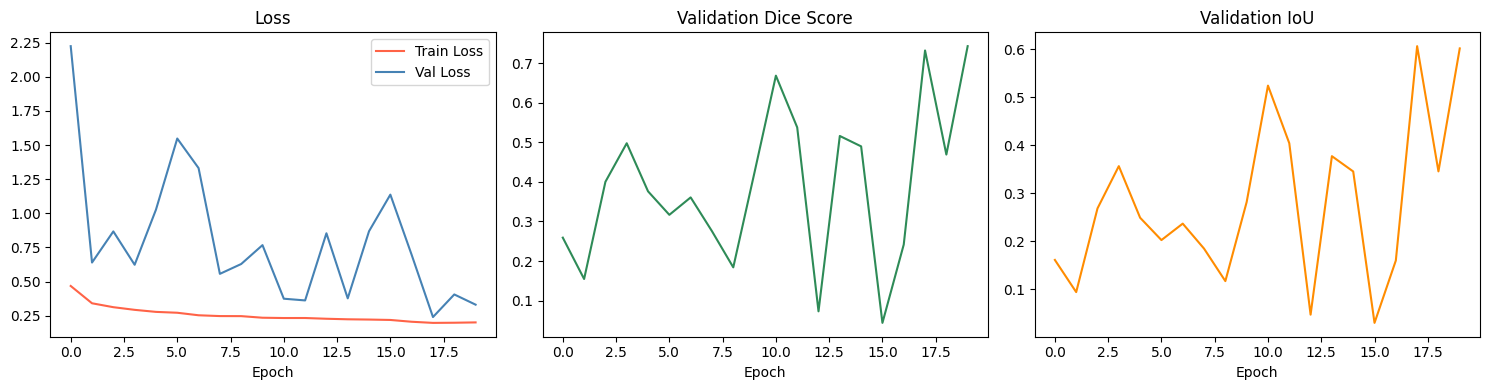

Training curves saved as training_curves.png

Running inference on sample patches...


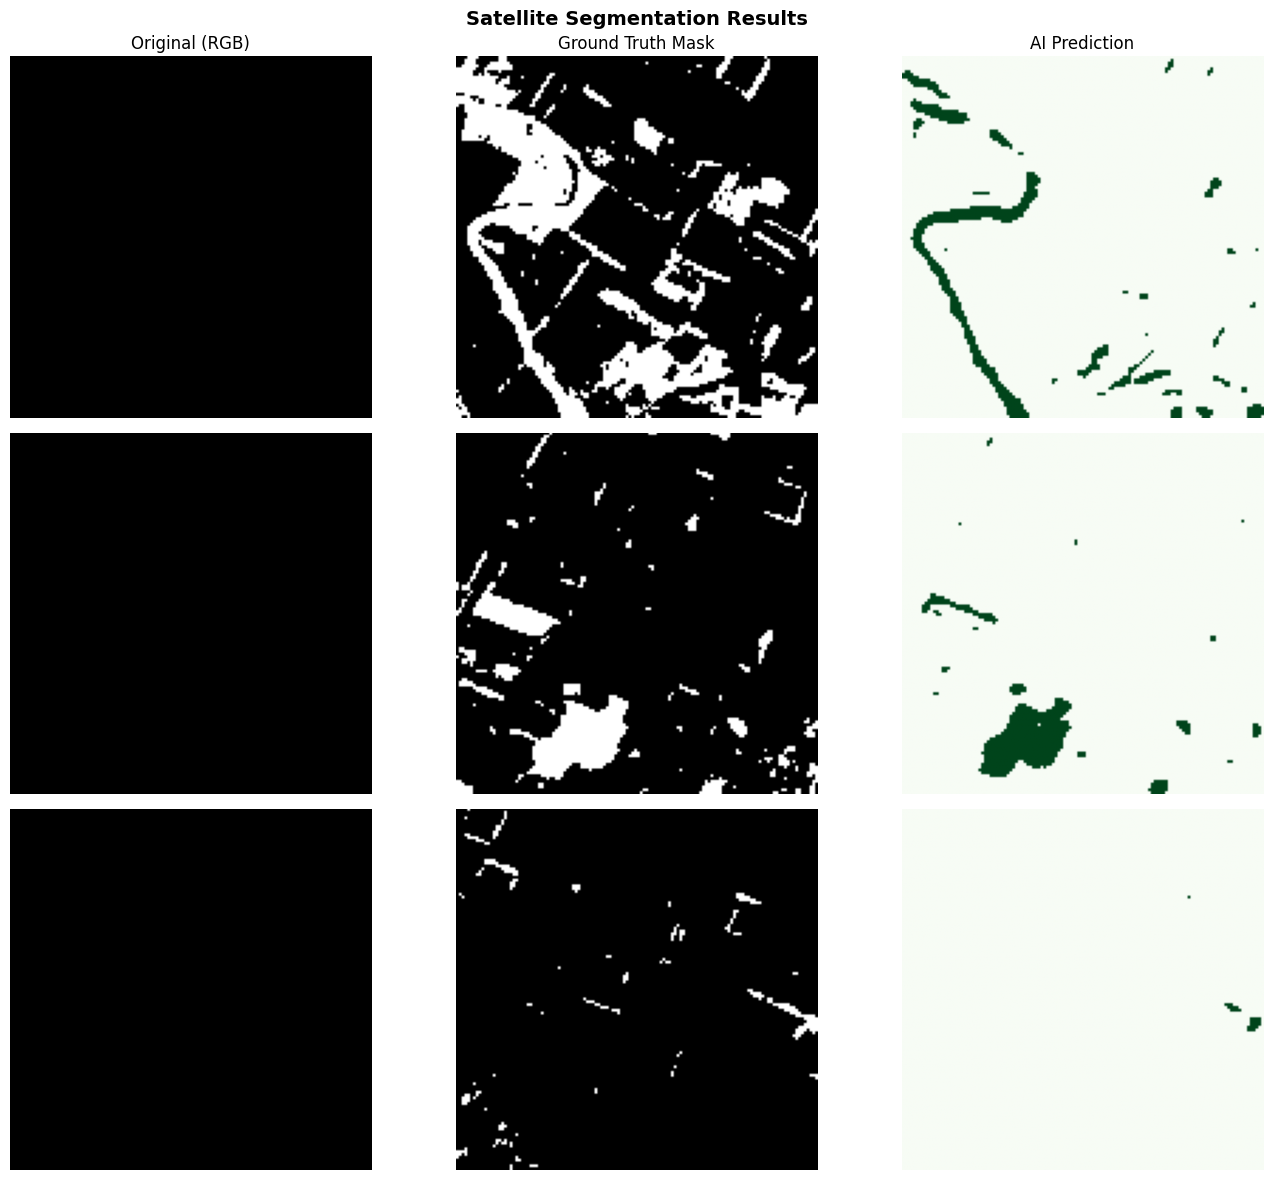

Results saved as segmentation_results.png

Done.


In [ ]:
# ==========================================
# 1. INSTALLATION & GPU SETUP
# ==========================================
!pip install -q segmentation-models-pytorch albumentations rasterio kagglehub

import os, glob, torch, rasterio, kagglehub
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm

# Clear GPU Memory
torch.cuda.empty_cache()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ==========================================
# 2. DATA DOWNLOAD & PATH VERIFICATION
# ==========================================
print("Setting up data...")
try:
    path = kagglehub.dataset_download("knowhrishi/liss-ivdata")
    all_files = glob.glob(os.path.join(path, "**", "*.tif"), recursive=True)
except Exception as e:
    print(f"Kaggle download failed: {e}")
    all_files = []

if len(all_files) == 0:
    all_files = glob.glob("*.tif")

print(f"Total satellite files located: {len(all_files)}")

if len(all_files) == 0:
    raise FileNotFoundError("No .tif files found. Please upload your satellite data.")

# ==========================================
# 3. TRAIN / VAL SPLIT
# ==========================================
import random
random.seed(42)
random.shuffle(all_files)

split = int(0.8 * len(all_files))
train_files = all_files[:split] if split > 0 else all_files
val_files   = all_files[split:] if split < len(all_files) else all_files[:1]

print(f"Train files: {len(train_files)} | Val files: {len(val_files)}")

# ==========================================
# 4. LOSS FUNCTIONS
# ==========================================
class FocalTverskyLoss(nn.Module):
    """
    Focal Tversky Loss — good for imbalanced segmentation tasks.
    alpha: penalizes False Positives
    beta:  penalizes False Negatives (increase for recall-focused tasks)
    gamma: focal factor — higher = more focus on hard examples
    """
    def __init__(self, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        probs   = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1).float()
        TP = (probs * targets).sum()
        FP = ((1 - targets) * probs).sum()
        FN = (targets * (1 - probs)).sum()
        tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        return torch.pow((1 - tversky), self.gamma)


class CombinedLoss(nn.Module):
    """
    BCE + Focal Tversky combined — more stable training than Tversky alone.
    """
    def __init__(self):
        super().__init__()
        self.bce     = nn.BCEWithLogitsLoss()
        self.tversky = FocalTverskyLoss()

    def forward(self, logits, targets):
        return 0.5 * self.bce(logits, targets) + 0.5 * self.tversky(logits, targets)


# ==========================================
# 5. DATASET CLASS
# ==========================================
class SatelliteDataset(Dataset):
    def __init__(self, file_list, patch_size=128, transform=None):
        self.patch_size = patch_size
        self.transform  = transform
        self.patches    = []

        for f in file_list:
            try:
                with rasterio.open(f) as src:
                    h, w = src.height, src.width
                    if h >= patch_size and w >= patch_size:
                        for i in range(0, h - patch_size, patch_size):
                            for j in range(0, w - patch_size, patch_size):
                                self.patches.append((f, i, j))
            except Exception as e:
                print(f"Skipping {f}: {e}")
                continue

        print(f"  Dataset built: {len(self.patches)} patches from {len(file_list)} files")

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, index):          # renamed from idx to avoid shadowing
        path, y, x = self.patches[index]

        with rasterio.open(path) as src:
            window    = rasterio.windows.Window(x, y, self.patch_size, self.patch_size)
            num_bands = src.count

            # Always read exactly 3 bands for RGB
            if num_bands >= 3:
                band_indices = [1, 2, 3]
            else:
                band_indices = list(range(1, num_bands + 1))

            img = src.read(band_indices, window=window).astype(np.float32)

            # Ensure 3-channel output
            if img.shape[0] == 1:
                img = np.repeat(img, 3, axis=0)      # grayscale → RGB
            elif img.shape[0] == 2:
                img = np.concatenate([img, img[:1]], axis=0)   # 2-band → 3

            # CHW → HWC for albumentations
            img = img.transpose(1, 2, 0)

            # Normalize to [0, 1]
            min_v, max_v = img.min(), img.max()
            if max_v > min_v:
                img = (img - min_v) / (max_v - min_v)
            else:
                img = np.zeros_like(img)

            # ── Mask generation ──────────────────────────────────────────
            # NOTE: This uses NDVI-style heuristic (low reflectance = water/shadow).
            # Replace this block with your actual ground truth mask if available:
            #
            #   mask_path = path.replace(".tif", "_mask.tif")
            #   with rasterio.open(mask_path) as msrc:
            #       mask = msrc.read(1, window=window).astype(np.float32)
            #       mask = (mask > 0).astype(np.float32)   # binarize
            #
            # Heuristic fallback: dark pixels (intensity < 0.2) as foreground
            gray = img.mean(axis=2)
            mask = (gray < 0.2).astype(np.float32)
            # ─────────────────────────────────────────────────────────────

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img  = augmented["image"]
            mask = augmented["mask"].float().unsqueeze(0)   # (1, H, W)

        return img, mask


# ==========================================
# 6. METRICS
# ==========================================
def dice_score(pred_logits, targets, threshold=0.5, smooth=1e-6):
    preds   = (torch.sigmoid(pred_logits) > threshold).float()
    targets = targets.float()
    intersection = (preds * targets).sum()
    return ((2 * intersection + smooth) / (preds.sum() + targets.sum() + smooth)).item()

def iou_score(pred_logits, targets, threshold=0.5, smooth=1e-6):
    preds   = (torch.sigmoid(pred_logits) > threshold).float()
    targets = targets.float()
    intersection = (preds * targets).sum()
    union        = preds.sum() + targets.sum() - intersection
    return ((intersection + smooth) / (union + smooth)).item()


# ==========================================
# 7. TRANSFORMS
# ==========================================
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ==========================================
# 8. DATASETS & DATALOADERS
# ==========================================
train_ds = SatelliteDataset(train_files, patch_size=128, transform=train_transform)
val_ds   = SatelliteDataset(val_files,   patch_size=128, transform=val_transform)

if len(train_ds) == 0:
    raise RuntimeError("No valid patches found in training files.")

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=2, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=2, drop_last=False)

# ==========================================
# 9. MODEL, OPTIMIZER, SCHEDULER
# ==========================================
model = smp.Unet(
    encoder_name    = "resnet34",
    encoder_weights = "imagenet",   # pretrained weights — faster convergence
    in_channels     = 3,
    classes         = 1,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                        patience=3, factor=0.5)
criterion = CombinedLoss()

# ==========================================
# 10. TRAINING LOOP
# ==========================================
EPOCHS = 20
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}

print(f"\nStarting training for {EPOCHS} epochs on {len(train_ds)} patches...")

for epoch in range(1, EPOCHS + 1):

    # ── Train ──
    model.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [Train]")
    for img, mask in pbar:
        img, mask = img.to(DEVICE), mask.to(DEVICE)
        optimizer.zero_grad()
        output = model(img)
        loss   = criterion(output, mask)
        if torch.isnan(loss):
            print("  NaN loss detected — skipping batch")
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})

    train_loss /= max(len(train_loader), 1)

    # ── Validate ──
    model.eval()
    val_loss = val_dice = val_iou = 0.0
    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.to(DEVICE), mask.to(DEVICE)
            output    = model(img)
            val_loss += criterion(output, mask).item()
            val_dice += dice_score(output, mask)
            val_iou  += iou_score(output, mask)

    n = max(len(val_loader), 1)
    val_loss /= n
    val_dice /= n
    val_iou  /= n

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)

    print(f"  Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  ✓ Best model saved (val_loss={val_loss:.4f})")

# ==========================================
# 11. TRAINING CURVES
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="Train Loss", color="tomato")
axes[0].plot(history["val_loss"],   label="Val Loss",   color="steelblue")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history["val_dice"], color="seagreen")
axes[1].set_title("Validation Dice Score"); axes[1].set_xlabel("Epoch")

axes[2].plot(history["val_iou"], color="darkorange")
axes[2].set_title("Validation IoU"); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Training curves saved as training_curves.png")

# ==========================================
# 12. INFERENCE & VISUALIZATION
# ==========================================
print("\nRunning inference on sample patches...")

# Load best weights
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes[0][0].set_title("Original (RGB)",  fontsize=12)
axes[0][1].set_title("Ground Truth Mask", fontsize=12)
axes[0][2].set_title("AI Prediction",  fontsize=12)

num_samples = min(3, len(val_ds))
for i in range(num_samples):
    img_tensor, mask_tensor = val_ds[i]

    with torch.no_grad():
        pred = torch.sigmoid(model(img_tensor.unsqueeze(0).to(DEVICE)))
        pred = pred.cpu().numpy()[0][0]   # (H, W)

    # Denormalize for display
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_display = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_display = img_display * std + mean
    img_display = np.clip(img_display, 0, 1)

    mask_display = mask_tensor.squeeze().cpu().numpy()

    axes[i][0].imshow(img_display)
    axes[i][0].axis("off")

    axes[i][1].imshow(mask_display, cmap="gray")
    axes[i][1].axis("off")

    axes[i][2].imshow(pred > 0.5, cmap="Greens")
    axes[i][2].axis("off")

plt.suptitle("Satellite Segmentation Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("segmentation_results.png", dpi=150)
plt.show()
print("Results saved as segmentation_results.png")
print("\nDone.")